# EDA do Case CVM

Este notebook resume a qualidade da base, a definição do universo de análise e o comportamento do target construído para o case.

Objetivo desta etapa:
- validar se a base está consistente com o escopo pedido
- entender o tamanho da amostra e as principais limitações
- inspecionar a distribuição do target antes da modelagem
- deixar evidentes os guardas básicos contra vazamento

In [1]:
import numpy as np


In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

BASE_DIR = Path.cwd().resolve().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

FUNDS_RAW_PATH = PROCESSED_DIR / "funds_raw.parquet"
FUNDS_SCOPE_PATH = PROCESSED_DIR / "funds_scope.parquet"
RAW_QUALITY_PATH = PROCESSED_DIR / "funds_raw_quality.json"
SCOPE_SUMMARY_PATH = PROCESSED_DIR / "funds_scope_summary.json"
MANUAL_VALIDATION_PATH = PROCESSED_DIR / "manual_validation_samples.json"

df_raw = pd.read_parquet(FUNDS_RAW_PATH)
df_scope = pd.read_parquet(FUNDS_SCOPE_PATH)

with open(RAW_QUALITY_PATH, "r", encoding="utf-8") as file:
    raw_quality = json.load(file)

with open(SCOPE_SUMMARY_PATH, "r", encoding="utf-8") as file:
    scope_summary = json.load(file)

with open(MANUAL_VALIDATION_PATH, "r", encoding="utf-8") as file:
    manual_validation = json.load(file)

## 1. Visão geral dos artefatos

Nesta etapa eu já trabalho com duas camadas de dados:
- `funds_raw.parquet`: base consolidada do informe diário com cadastro
- `funds_scope.parquet`: base filtrada no escopo do case e com target pronto

In [3]:
resumo_geral = pd.DataFrame([
    {
        "base": "funds_raw",
        "linhas": len(df_raw),
        "cnpjs": df_raw["CNPJ_FUNDO"].nunique(),
        "entidades": df_raw["ENTITY_KEY"].nunique(),
        "data_inicial": df_raw["DT_COMPTC"].min().date(),
        "data_final": df_raw["DT_COMPTC"].max().date(),
    },
    {
        "base": "funds_scope",
        "linhas": len(df_scope),
        "cnpjs": df_scope["CNPJ_FUNDO"].nunique(),
        "entidades": df_scope["ENTITY_KEY"].nunique(),
        "data_inicial": df_scope["DT_COMPTC"].min().date(),
        "data_final": df_scope["DT_COMPTC"].max().date(),
    },
])

resumo_geral

,base,linhas,cnpjs,entidades,data_inicial,data_final
0,funds_raw,12418272,32073,32537,2024-05-01,2026-04-10
1,funds_scope,1751278,3827,3888,2024-05-01,2026-04-10


## 2. Qualidade da base consolidada

O ponto mais importante aqui é mostrar que a base não foi apenas concatenada: houve limpeza, deduplicação e documentação do merge com o cadastro.

In [4]:
qualidade_resumo = pd.DataFrame([
    {
        "métrica": "linhas após merge",
        "valor": raw_quality["merge"]["rows_after_merge"],
    },
    {
        "métrica": "fundos após merge",
        "valor": raw_quality["merge"]["funds_after_merge"],
    },
    {
        "métrica": "taxa de match com cadastro",
        "valor": raw_quality["merge"]["merge_hit_rate"],
    },
    {
        "métrica": "linhas sem match no cadastro",
        "valor": raw_quality["merge"]["rows_without_registry_match"],
    },
    {
        "métrica": "linhas duplicadas detectadas",
        "valor": raw_quality["daily_data"]["duplicate_rows_before_cleaning"],
    },
    {
        "métrica": "chaves duplicadas detectadas",
        "valor": raw_quality["daily_data"]["duplicate_keys_before_cleaning"],
    },
    {
        "métrica": "chaves duplicadas com conflito",
        "valor": raw_quality["daily_data"]["conflicting_duplicate_keys"],
    },
])

qualidade_resumo

,métrica,valor
0,linhas após merge,"12,418,272.0000"
1,fundos após merge,"32,073.0000"
2,taxa de match com cadastro,0.7980
3,linhas sem match no cadastro,"2,508,308.0000"
4,linhas duplicadas detectadas,"78,963.0000"
5,chaves duplicadas detectadas,"39,479.0000"
6,chaves duplicadas com conflito,"8,660.0000"


In [5]:
pd.DataFrame({
    "regra_de_limpeza": raw_quality["cleaning_rules"]
})

,regra_de_limpeza
0,Padronização de chave CNPJ removendo pontuação.
1,Conversão de datas com tratamento de erro para...
2,Criação de chave da entidade por classe/subcla...
3,Deduplicação do informe diário mantendo uma li...
4,"Em duplicidades da mesma entidade, preferência..."
5,Validação de conflitos em duplicidades usando ...
6,Deduplicação do cadastro por CNPJ escolhendo o...


Leitura desta seção:
- a granularidade relevante para modelagem passou a ser `ENTITY_KEY`, e não apenas `CNPJ_FUNDO`
- isso evita misturar subclasses distintas no mesmo histórico
- a taxa de match com cadastro deve ser documentada como limitação da cobertura de metadata

## 3. Definição do universo do case

O escopo adotado foi:
- classe `Ações`
- situação `Em Funcionamento Normal`
- pelo menos 50 observações por entidade

In [6]:
pd.DataFrame([
    {
        "item": "classificação",
        "valor": scope_summary["scope_definition"]["classificacao"],
    },
    {
        "item": "situação",
        "valor": scope_summary["scope_definition"]["situacao"],
    },
    {
        "item": "mínimo de observações por entidade",
        "valor": scope_summary["scope_definition"]["min_observations_per_fund"],
    },
    {
        "item": "linhas após filtro de escopo",
        "valor": scope_summary["sample"]["rows_after_scope_filter"],
    },
    {
        "item": "linhas prontas para modelagem",
        "valor": scope_summary["sample"]["rows_model_ready"],
    },
    {
        "item": "entidades elegíveis",
        "valor": scope_summary["sample"]["eligible_entities"],
    },
    {
        "item": "CNPJs no escopo",
        "valor": scope_summary["sample"]["eligible_class_cnpjs"],
    },
    {
        "item": "período inicial",
        "valor": scope_summary["sample"]["period_start"],
    },
    {
        "item": "período final",
        "valor": scope_summary["sample"]["period_end"],
    },
])

,item,valor
0,classificação,Ações
1,situação,Em Funcionamento Normal
2,mínimo de observações por entidade,50
3,linhas após filtro de escopo,1751278
4,linhas prontas para modelagem,1665525
5,entidades elegíveis,3888
6,CNPJs no escopo,3827
7,período inicial,2024-05-01
8,período final,2026-04-10


In [7]:
historico_por_entidade = df_scope.groupby("ENTITY_KEY").size().rename("n_observacoes")

historico_por_entidade.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count   3,888.0000
mean      450.4316
std        99.2095
min        50.0000
10%       313.4000
25%       488.0000
50%       489.0000
75%       489.0000
90%       489.0000
99%       490.0000
max       491.0000
Name: n_observacoes, dtype: float64

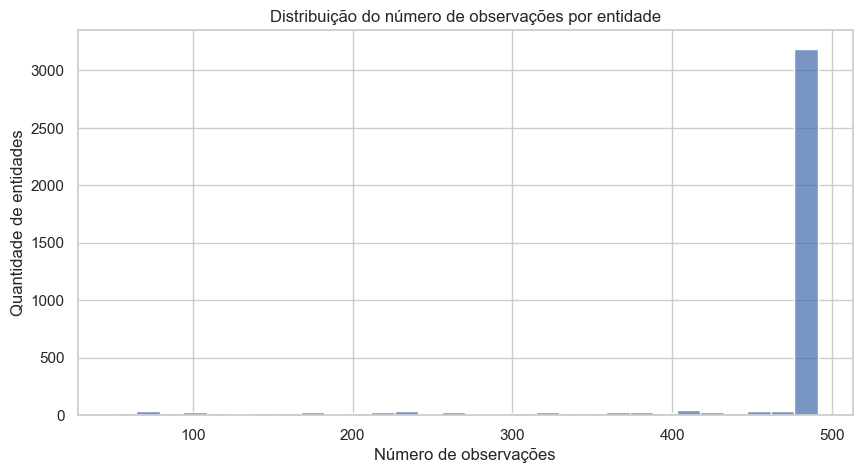

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(historico_por_entidade, bins=30)
plt.title("Distribuição do número de observações por entidade")
plt.xlabel("Número de observações")
plt.ylabel("Quantidade de entidades")
plt.show()

## 4. Entendendo o target

O target definido foi o fluxo líquido futuro acumulado de `T+1` a `T+21` dias úteis, normalizado pelo `PL` defasado em 1 dia.

Esse target tem três características importantes:
- muitos valores exatamente iguais a zero
- forte assimetria
- presença de poucos outliers extremos, geralmente associados a PLs muito pequenos

In [9]:
target = df_scope.loc[df_scope["is_model_ready"], "target_flow_pct_t1_t21"].copy()

pd.DataFrame([
    {"métrica": "mediana", "valor": target.median()},
    {"métrica": "p01", "valor": target.quantile(0.01)},
    {"métrica": "p05", "valor": target.quantile(0.05)},
    {"métrica": "p95", "valor": target.quantile(0.95)},
    {"métrica": "p99", "valor": target.quantile(0.99)},
    {"métrica": "% de zeros", "valor": target.eq(0).mean()},
    {"métrica": "% com |target| > 1", "valor": target.abs().gt(1).mean()},
])

,métrica,valor
0,mediana,0.0000
1,p01,-0.3050
2,p05,-0.1074
3,p95,0.0778
4,p99,0.4360
5,% de zeros,0.3644
6,% com |target| > 1,0.0042


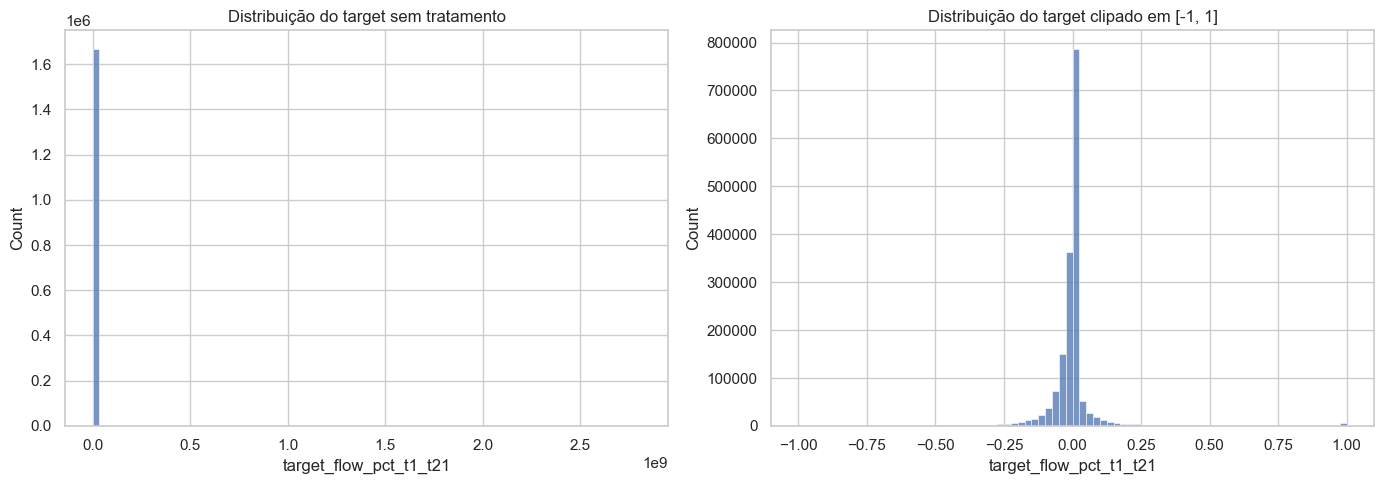

In [10]:
target_clipado = target.clip(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(target, bins=80, ax=axes[0])
axes[0].set_title("Distribuição do target sem tratamento")
axes[0].set_xlabel("target_flow_pct_t1_t21")

sns.histplot(target_clipado, bins=80, ax=axes[1])
axes[1].set_title("Distribuição do target clipado em [-1, 1]")
axes[1].set_xlabel("target_flow_pct_t1_t21")

plt.tight_layout()
plt.show()

In [11]:
extremos = df_scope.loc[df_scope["is_model_ready"]].copy()
extremos = extremos.assign(abs_target=extremos["target_flow_pct_t1_t21"].abs())

extremos.nlargest(10, "abs_target")[[
    "ENTITY_KEY",
    "CNPJ_FUNDO",
    "Denominacao_Social",
    "DT_COMPTC",
    "pl_lag1",
    "target_flow_t1_t21",
    "target_flow_pct_t1_t21",
]]

,ENTITY_KEY,CNPJ_FUNDO,Denominacao_Social,DT_COMPTC,pl_lag1,target_flow_t1_t21,target_flow_pct_t1_t21
1655245,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-17,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655246,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-18,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655247,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-19,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655248,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-20,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655249,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-23,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655250,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-24,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655251,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-25,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655252,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-26,0.0100,"28,088,657.6700","2,808,865,767.0000"
1655253,56905583000154::SEM_SUBCLASSE,56905583000154,OBLAST FUNDO DE INVESTIMENTO FINANCEIRO EM AÇÕES,2024-09-27,0.0100,"28,088,657.6700","2,808,865,767.0000"
1527835,53306332000165::SEM_SUBCLASSE,53306332000165,GENOMA PG FUNDO DE INVESTIMENTO EM AÇÕES,2024-05-03,0.0100,"348,000.0000","34,800,000.0000"


Leitura desta seção:
- a mediana do target em zero sugere baixa frequência de movimentos relevantes para boa parte da amostra
- a presença de outliers reforça a necessidade de winsorização, clipping ou métricas robustas
- isso também favorece uma análise complementar de classificação em top decile, se você quiser usar como apêndice

## 5. Sinais econômicos preliminares

Antes de modelar, vale olhar se retorno recente e tamanho parecem se relacionar com fluxo futuro.

In [12]:
eda = df_scope.loc[df_scope["is_model_ready"]].copy()
eda["log_pl_lag1"] = eda["pl_lag1"].where(eda["pl_lag1"] > 0).map(lambda x: None if pd.isna(x) else np.log10(x))
eda["ret_21d"] = eda.groupby("ENTITY_KEY")["VL_QUOTA"].pct_change(21)
eda["quintil_ret_21d"] = pd.qcut(eda["ret_21d"], q=5, labels=False, duplicates="drop")
eda["quintil_log_pl"] = pd.qcut(eda["log_pl_lag1"], q=5, labels=False, duplicates="drop")

retorno_vs_fluxo = eda.groupby("quintil_ret_21d", dropna=False)["target_flow_pct_t1_t21"].median().reset_index()
tamanho_vs_fluxo = eda.groupby("quintil_log_pl", dropna=False)["target_flow_pct_t1_t21"].median().reset_index()

display(retorno_vs_fluxo)
display(tamanho_vs_fluxo)

,quintil_ret_21d,target_flow_pct_t1_t21
0,0.0000,0.0000
1,1.0000,0.0000
2,2.0000,0.0000
3,3.0000,0.0000
4,4.0000,0.0000
5,NaN,0.0000


,quintil_log_pl,target_flow_pct_t1_t21
0,0,0.0000
1,1,0.0000
2,2,0.0000
3,3,0.0000
4,4,0.0000


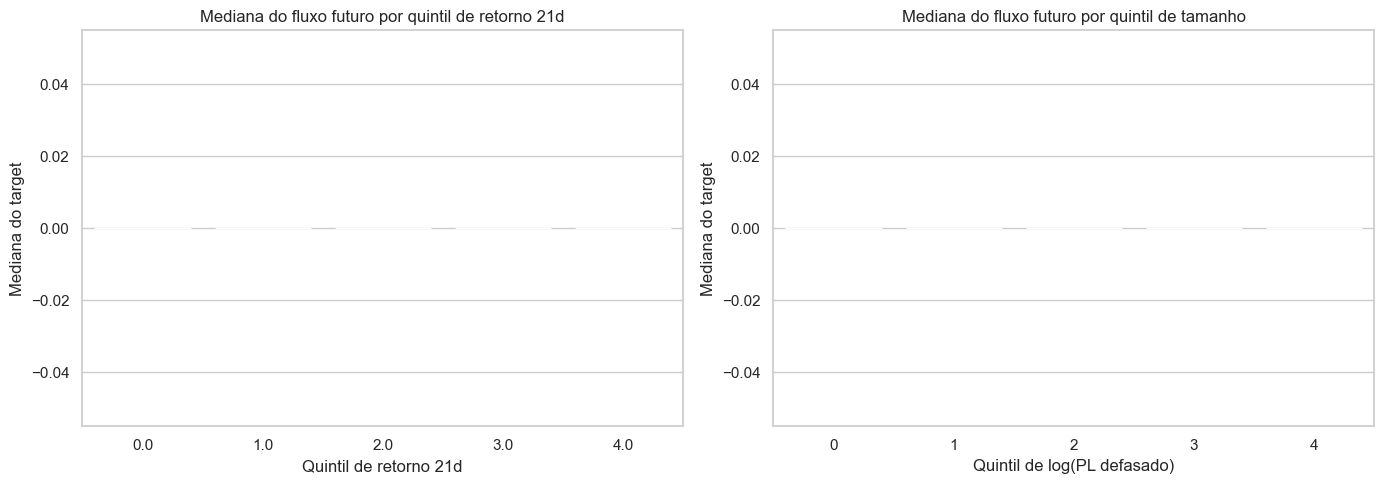

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=retorno_vs_fluxo, x="quintil_ret_21d", y="target_flow_pct_t1_t21", ax=axes[0], color="#1f77b4")
axes[0].set_title("Mediana do fluxo futuro por quintil de retorno 21d")
axes[0].set_xlabel("Quintil de retorno 21d")
axes[0].set_ylabel("Mediana do target")

sns.barplot(data=tamanho_vs_fluxo, x="quintil_log_pl", y="target_flow_pct_t1_t21", ax=axes[1], color="#ff7f0e")
axes[1].set_title("Mediana do fluxo futuro por quintil de tamanho")
axes[1].set_xlabel("Quintil de log(PL defasado)")
axes[1].set_ylabel("Mediana do target")

plt.tight_layout()
plt.show()

## 6. Guardas anti-vazamento

A principal regra aqui é simples:
- `pl_lag1` usa apenas informação conhecida até `T`
- o target começa em `T+1`
- portanto a linha de modelagem nunca usa o próprio fluxo futuro como feature

In [14]:
exemplo = (
    df_scope.loc[df_scope["is_model_ready"]]
    .sort_values(["ENTITY_KEY", "DT_COMPTC"])
    .groupby("ENTITY_KEY")
    .head(30)
    .iloc[:10]
)[[
    "ENTITY_KEY",
    "DT_COMPTC",
    "VL_PATRIM_LIQ",
    "pl_lag1",
    "flow_dia",
    "target_flow_t1_t21",
    "target_flow_pct_t1_t21",
]]

exemplo

,ENTITY_KEY,DT_COMPTC,VL_PATRIM_LIQ,pl_lag1,flow_dia,target_flow_t1_t21,target_flow_pct_t1_t21
1,10141924000161::SEM_SUBCLASSE,2024-05-03,"1,068,141,033.8500","1,047,957,590.9600",0.0000,0.0000,0.0000
2,10141924000161::SEM_SUBCLASSE,2024-05-06,"1,064,199,154.6100","1,068,141,033.8500",0.0000,0.0000,0.0000
3,10141924000161::SEM_SUBCLASSE,2024-05-07,"1,065,386,661.8900","1,064,199,154.6100",0.0000,0.0000,0.0000
4,10141924000161::SEM_SUBCLASSE,2024-05-08,"1,071,371,282.1300","1,065,386,661.8900",0.0000,0.0000,0.0000
5,10141924000161::SEM_SUBCLASSE,2024-05-09,"1,058,611,527.7500","1,071,371,282.1300",0.0000,0.0000,0.0000
6,10141924000161::SEM_SUBCLASSE,2024-05-10,"1,053,624,635.7900","1,058,611,527.7500",0.0000,0.0000,0.0000
7,10141924000161::SEM_SUBCLASSE,2024-05-13,"1,056,050,958.1700","1,053,624,635.7900",0.0000,0.0000,0.0000
8,10141924000161::SEM_SUBCLASSE,2024-05-14,"1,059,796,239.1900","1,056,050,958.1700",0.0000,0.0000,0.0000
9,10141924000161::SEM_SUBCLASSE,2024-05-15,"1,064,571,860.1200","1,059,796,239.1900",0.0000,0.0000,0.0000
10,10141924000161::SEM_SUBCLASSE,2024-05-16,"1,069,203,471.7700","1,064,571,860.1200",0.0000,0.0000,0.0000


## 7. Validação manual contra o bruto

O case pede conferir manualmente 2 fundos e 3 datas. A checagem abaixo foi gerada a partir do arquivo bruto mensal correspondente.

In [15]:
validacao_rows = []

for item in manual_validation:
    for campo, detalhes in item["comparison"].items():
        validacao_rows.append({
            "entity_key": item["entity_key"],
            "dt_comptc": item["dt_comptc"],
            "campo": campo,
            "valor_bruto": detalhes["raw"],
            "valor_processado": detalhes["processed"],
            "match": detalhes["match"],
        })

validacao_df = pd.DataFrame(validacao_rows)
display(validacao_df)
display(validacao_df["match"].value_counts(dropna=False))

,entity_key,dt_comptc,campo,valor_bruto,valor_processado,match
0,10141924000161::SEM_SUBCLASSE,2024-05-03,CAPTC_DIA,0.0000,0.0000,True
1,10141924000161::SEM_SUBCLASSE,2024-05-03,RESG_DIA,0.0000,0.0000,True
2,10141924000161::SEM_SUBCLASSE,2024-05-03,VL_PATRIM_LIQ,"1,068,141,033.8500","1,068,141,033.8500",True
3,10141924000161::SEM_SUBCLASSE,2024-05-03,VL_QUOTA,2.6879,2.6879,True
4,10141924000161::SEM_SUBCLASSE,2024-05-06,CAPTC_DIA,0.0000,0.0000,True
5,10141924000161::SEM_SUBCLASSE,2024-05-06,RESG_DIA,0.0000,0.0000,True
6,10141924000161::SEM_SUBCLASSE,2024-05-06,VL_PATRIM_LIQ,"1,064,199,154.6100","1,064,199,154.6100",True
7,10141924000161::SEM_SUBCLASSE,2024-05-06,VL_QUOTA,2.6780,2.6780,True
8,10141924000161::SEM_SUBCLASSE,2024-05-07,CAPTC_DIA,0.0000,0.0000,True
9,10141924000161::SEM_SUBCLASSE,2024-05-07,RESG_DIA,0.0000,0.0000,True


match
True    24
Name: count, dtype: int64

## 8. Conclusões do EDA

Principais leituras até aqui:
- a base já cobre aproximadamente 24 meses e possui volume suficiente para modelagem
- o universo final de `Ações` em funcionamento normal ficou grande o bastante para uma análise robusta
- o target é bastante assimétrico e com muitos zeros, o que pede tratamento de outliers e métricas robustas
- a granularidade por entidade foi um ajuste importante para evitar mistura de subclasses
- a validação manual confirma que os campos críticos do informe diário estão coerentes com o bruto

Próximos passos:
- construir features históricas sem vazamento
- fazer split temporal
- treinar um baseline de regressão e interpretar os drivers